In [9]:
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output
import matplotlib.ticker as ticker
import subprocess

In [10]:
def entrada(algoritmo: str, n: int) -> float:
    grafo = subprocess.run(
        ["python", "script_cycle_graph.py", str(n), str(n)],
        capture_output=True, text=True
    ).stdout

    result = subprocess.run(
        ["docker", "run", "--rm", "-i", "scc-graph-project-java", algoritmo],
        input=grafo,
        capture_output=True,
        text=True
    )
    return float(result.stdout.strip())

In [11]:
def benchmark(entrada_maxima: int = 10000, pulo: int = 100, epocas: int = 100) -> None:
    """
    Executa o benchmark de Tarjan e Kosaraju e plota o gráfico comparativo em tempo real.
    Para cada tamanho de entrada, roda cada algoritmo 'epocas' vezes e calcula
    o tempo médio, atualizando o gráfico a cada iteração.

    :param entrada_maxima: limite superior do tamanho da entrada (exclusivo)
    :type entrada_maxima: int
    :param pulo: incremento entre cada tamanho de entrada testado
    :type pulo: int
    :param epocas: número de execuções por tamanho de entrada para calcular a média
    :type epocas: int
    :return: None
    """

    xs = []
    ys_tarjan = []
    ys_kosaraju = []

    for i in range(1, entrada_maxima, pulo):
        start = time.perf_counter()
        for j in range(epocas):
            entrada("tarjan", i)
        ys_tarjan.append((time.perf_counter() - start) / epocas)

        start = time.perf_counter()
        for j in range(epocas):
            entrada("kosaraju", i)
        ys_kosaraju.append((time.perf_counter() - start) / epocas)

        xs.append(i)
        clear_output(wait=True)

        fig, ax = plt.subplots(figsize=(9, 5))
        fig.patch.set_facecolor("#0f0f0f")
        ax.set_facecolor("#1a1a2e")

        # Tarjan
        ax.fill_between(xs, ys_tarjan, alpha=0.15, color="#00d4ff")
        ax.plot(xs, ys_tarjan, color="#00d4ff", linewidth=2.5, marker='o', markersize=7,
                markerfacecolor="#ff6b6b", markeredgecolor="white", markeredgewidth=1.2,
                zorder=5, label="Tarjan")

        # Kosaraju
        ax.fill_between(xs, ys_kosaraju, alpha=0.15, color="#a29bfe")
        ax.plot(xs, ys_kosaraju, color="#a29bfe", linewidth=2.5, marker='o', markersize=7,
                markerfacecolor="#ff6b6b", markeredgecolor="white", markeredgewidth=1.2,
                zorder=5, label="Kosaraju")

        for x, y in zip(xs, ys_tarjan):
            ax.annotate(f"{y*1000:.2f}ms", xy=(x, y), xytext=(0, 10),
                        textcoords="offset points", ha='center', fontsize=7.5, color="#00d4ff")

        for x, y in zip(xs, ys_kosaraju):
            ax.annotate(f"{y*1000:.2f}ms", xy=(x, y), xytext=(0, -15),
                        textcoords="offset points", ha='center', fontsize=7.5, color="#a29bfe")

        ax.grid(color="#ffffff", linestyle="--", linewidth=0.4, alpha=0.15)
        for spine in ax.spines.values():
            spine.set_edgecolor("#333355")
        ax.set_xlabel("Tamanho da entrada (n)", color="white", fontsize=11)
        ax.set_ylabel("Tempo médio (ms)", color="white", fontsize=11)
        ax.set_title("⏱ Tarjan vs Kosaraju — Tempo de Execução", color="white", fontsize=13, pad=14)
        ax.tick_params(colors="white")
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v*1000:.2f}ms"))
        legend = ax.legend(facecolor="#1a1a2e", edgecolor="#333355", labelcolor="white")
        plt.tight_layout()
        plt.show()
        plt.close(fig)

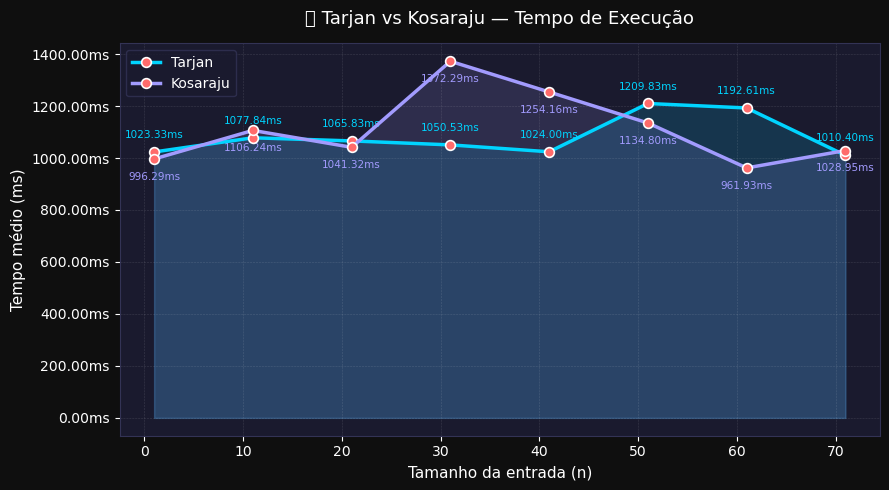

KeyboardInterrupt: 

In [14]:
benchmark(100, 10, 10)